# 4.5 Regionalisation: Spatially Constrained Clustering

**Part:** 4 — Spatial Cluster Analysis (Chapter 4.5 of 8)

**Dataset:** `diabetes_northeast.shp` (217 counties)

**Focus:** Grouping counties into contiguous, internally homogeneous regions — SKATER and constrained agglomerative clustering

**Library:** `spatialstats.cluster` (PySpatialStats)

***

## Table of Contents

1.. [Overview](#1.-Overview)
2.. [Python Setup](#2.-Python-Setup)
3.. [SKATER: A Minimum Spanning Tree, Cut Repeatedly](#3.-SKATER:-A-Minimum-Spanning-Tree,-Cut-Repeatedly)
4.. [Constrained Agglomerative Clustering](#4.-Constrained-Agglomerative-Clustering)
   - 4.1 [A real contiguity gap](#4.1-A-real-contiguity-gap)
5.. [Islands, Minimum Size, and Population Floors](#5.-Islands,-Minimum-Size,-and-Population-Floors)
6.. [Validating and Choosing k](#6.-Validating-and-Choosing-k)
7.. [Summary and Conclusions](#7.-Summary-and-Conclusions)
8.. [Resources](#8.-Resources)

***
## 1. Overview

Every method so far in this Part *detects* clusters against a null hypothesis or a density threshold.
**Regionalisation** is a different kind of task entirely: given a fixed number $k$, partition *every* area into
$k$ new, spatially contiguous zones that are as internally homogeneous as possible in a chosen set of
attributes. There is no significance test — the question is not "is there a region here" but "what is the best
way to draw $k$ regions", and the answer always exists by construction.

| Step | What we do |
|------|------------|
| SKATER | Minimum-spanning-tree-based regionalisation, contiguous by construction |
| Constrained agglomerative | Ward clustering constrained by the neighbour graph — and a concrete case where it is **not** actually contiguous |
| Constraints | Minimum region size and a population floor, and what the one island in this data does to both |
| Validation | `evaluate_regions`, `is_contiguous`, and how to think about choosing $k$ |

***
## 2. Python Setup

In [1]:
import sys, warnings
from pathlib import Path

import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", category=DeprecationWarning)


def find_repo_root(start: Path = Path.cwd()) -> Path:
    for p in [start, *start.parents]:
        if (p / "pyproject.toml").exists() and (p / "data").is_dir():
            return p
    raise FileNotFoundError("Run this notebook from inside the PySpatialStats repository.")


ROOT = find_repo_root()
DATA = ROOT / "data"
try:
    import spatialstats
except ImportError:
    sys.path.insert(0, str(ROOT))
    import spatialstats

from spatialstats.weights import Queen
from spatialstats.cluster import skater, agglomerative, evaluate_regions, partition_agreement

plt.rcParams.update({
    "figure.dpi": 100, "savefig.dpi": 100, "font.size": 10, "axes.titlesize": 11,
    "axes.titleweight": "bold", "axes.spines.top": False, "axes.spines.right": False,
    "axes.grid": True, "grid.alpha": 0.25, "legend.frameon": False,
})
C = {"blue": "#2b6cb0", "red": "#c0392b", "green": "#2f855a", "orange": "#dd6b20",
     "grey": "#718096", "purple": "#6b46c1", "teal": "#2c7a7b"}

counties = gpd.read_file(DATA / "diabetes_northeast.shp")
w = Queen(counties)
attributes = counties[["Dia_pct", "Obesity", "SVI"]]
print(f"spatialstats : version {spatialstats.__version__}")
print(f"regionalising on: {list(attributes.columns)}, standardised (z-scores) by default")

spatialstats : version 0.2.0
regionalising on: ['Dia_pct', 'Obesity', 'SVI'], standardised (z-scores) by default


***
## 3. SKATER: A Minimum Spanning Tree, Cut Repeatedly

SKATER (Spatial 'K'luster Analysis by Tree Edge Removal) works in two steps: build a **minimum spanning tree**
of the neighbour graph, with each edge costed by the squared attribute distance between the two counties it
joins; then repeatedly **cut the edge whose removal most reduces total within-region sum of squares**, until
$k$ regions remain. Because every cut only ever splits a tree (never reconnects across a cut), every resulting
region is contiguous **by construction** — no exceptions.

In [2]:
regions_skater = skater(attributes, w, n_clusters=6)
print(f"SKATER: {regions_skater._stats['n_regions']} regions, R²={regions_skater.r2:.4f}")
print(f"region sizes: {sorted(regions_skater.sizes, reverse=True)}")
print(f"contiguous (verified directly)? {regions_skater.is_contiguous(w)}")

SKATER: 6 regions, R²=0.2723
region sizes: [np.int64(139), np.int64(46), np.int64(20), np.int64(6), np.int64(5), np.int64(1)]
contiguous (verified directly)? True


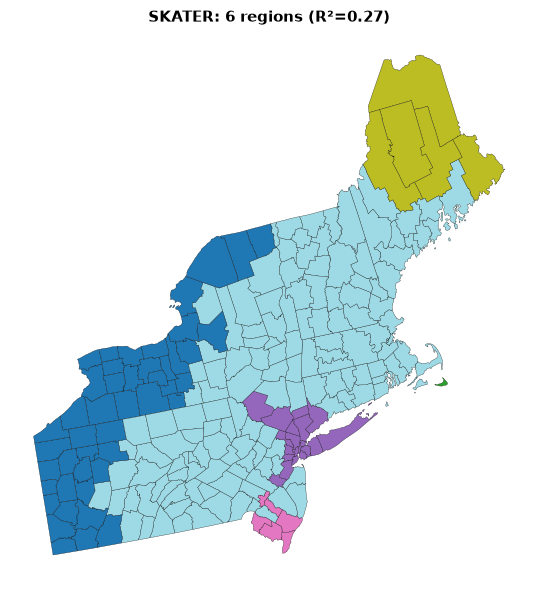

In [3]:
fig, ax = plt.subplots(figsize=(7, 6))
regions_skater.plot(gdf=counties, ax=ax)
plt.tight_layout()
plt.show()

$R^2=0.272$: about 27% of the total variation in `Dia_pct`, `Obesity`, and `SVI` (jointly, standardised) is
explained by which of the six regions a county belongs to — the rest is within-region variation the six-region
partition cannot capture. One region has only a single county: this is Nantucket, the same isolated island
found throughout Part 2 and Chapter 4.2, and Section 5 explains exactly why it always ends up alone.

***
## 4. Constrained Agglomerative Clustering

`agglomerative` runs scikit-learn's Ward hierarchical clustering with the neighbour graph as a **connectivity
constraint**: only adjacent clusters may merge at each step. In principle this should also guarantee
contiguous regions — but there is a documented caveat worth testing directly.

In [4]:
regions_agg = agglomerative(attributes, w, n_clusters=6, linkage="ward")
print(f"Constrained agglomerative: R²={regions_agg.r2:.4f}")
print(f"region sizes: {sorted(regions_agg.sizes, reverse=True)}")
print(f"contiguous (verified directly)? {regions_agg.is_contiguous(w)}")

Constrained agglomerative: R²=0.3496
region sizes: [np.int64(150), np.int64(37), np.int64(10), np.int64(9), np.int64(6), np.int64(5)]
contiguous (verified directly)? False


### 4.1 A real contiguity gap

**`is_contiguous(w)` returns `False`.** Agglomerative clustering achieves a *higher* $R^2$ (0.350 vs. SKATER's
0.272 — it is not constrained by a tree structure, so it can find a better attribute-based partition), but at
least one of its six regions is **not** a single connected block of counties. The reason: when the neighbour
graph has more than one connected component (here, the mainland plus the isolated Nantucket island),
scikit-learn's `AgglomerativeClustering` silently **completes** the connectivity graph rather than refusing to
merge across the gap — so nothing stops it from placing Nantucket in the same region as a mainland county it
does not actually touch.

In [5]:
# find which region violates contiguity, and confirm it is the island
from scipy.sparse.csgraph import connected_components
A = w.sparse.tocsr()
A = (A + A.T) > 0
for r in np.unique(regions_agg.labels):
    idx = np.flatnonzero(regions_agg.labels == r)
    ncomp, _ = connected_components(A[idx][:, idx], directed=False)
    if ncomp > 1:
        print(f"region {r}: {len(idx)} counties, {ncomp} disconnected pieces -> "
              f"{counties.iloc[idx][['FIPS','STATE','COUNTY']].to_string(index=False)}")

region 2: 150 counties, 2 disconnected pieces ->  FIPS         STATE                COUNTY
 9003   Connecticut       Hartford County
 9005   Connecticut     Litchfield County
 9007   Connecticut      Middlesex County
 9009   Connecticut      New Haven County
 9011   Connecticut     New London County
 9013   Connecticut        Tolland County
 9015   Connecticut        Windham County
23001         Maine   Androscoggin County
23005         Maine     Cumberland County
23007         Maine       Franklin County
23009         Maine        Hancock County
23011         Maine       Kennebec County
23013         Maine           Knox County
23015         Maine        Lincoln County
23017         Maine         Oxford County
23023         Maine      Sagadahoc County
23027         Maine          Waldo County
23031         Maine           York County
25001 Massachusetts     Barnstable County
25003 Massachusetts      Berkshire County
25005 Massachusetts        Bristol County
25007 Massachusetts        

**SKATER's tree-based construction cannot make this mistake**; constrained agglomerative clustering, despite
its name, needs its contiguity checked explicitly rather than assumed from the `connectivity=` argument alone —
this is exactly why `RegionResult.is_contiguous(w)` exists as a mandatory verification step, not an optional
extra.

In [6]:
agreement = partition_agreement(regions_skater.labels, regions_agg.labels)
print(f"SKATER vs. agglomerative partition agreement: "
      f"adjusted Rand = {agreement['adjusted_rand']:.3f}, NMI = {agreement['nmi']:.3f}")

SKATER vs. agglomerative partition agreement: adjusted Rand = 0.672, NMI = 0.670


Despite the contiguity difference, the two partitions agree moderately well overall (adjusted Rand 0.67) — most
of the disagreement is concentrated in exactly the boundary areas (like the island) where the contiguity
constraint actually bites.

***
## 5. Islands, Minimum Size, and Population Floors

`skater`'s `min_size` and `floor`/`floor_value` let a region-building exercise honour practical constraints —
e.g., every region should have at least a minimum population, the standard requirement for building
*stable-rate* regions in disease mapping (a direct bridge to Part 5).

In [7]:
with warnings.catch_warnings(record=True) as caught:
    warnings.simplefilter("always")
    regions_floor = skater(attributes, w, n_clusters=6, min_size=10,
                           floor=counties["POP_Total"], floor_value=1_400_000)
    for wmsg in caught:
        print("WARNING:", str(wmsg.message))
print(f"\nregion sizes: {sorted(regions_floor.sizes, reverse=True)}")


region sizes: [np.int64(80), np.int64(52), np.int64(46), np.int64(20), np.int64(18), np.int64(1)]


The warning names the exact problem: Nantucket (a disconnected component of size 1) **cannot** meet a minimum
size of 10 or a population floor of 1.4 million on its own, and it cannot be merged into any other region
either — since `skater` only ever cuts a *connected* tree, and the island was never connected to the mainland
tree in the first place. It always forms its own region and always violates the constraint, regardless of
`min_size` or `floor_value`. If this is not acceptable for a given application, the island must be linked to a
neighbour in `w` manually (Part 2, Chapter 2.2's island-handling options) before regionalising.

In [8]:
counties_no_island = counties.drop(index=w.islands()[0]).reset_index(drop=True)
w_no_island = Queen(counties_no_island)
print(f"islands after dropping Nantucket: {len(w_no_island.islands())}, "
      f"components: {w_no_island.n_components()}")

regions_clean = skater(counties_no_island[["Dia_pct", "Obesity", "SVI"]], w_no_island,
                       n_clusters=6, min_size=10, floor=counties_no_island["POP_Total"], floor_value=1_400_000)
region_pops = pd.Series(counties_no_island["POP_Total"].to_numpy()).groupby(regions_clean.labels).sum()
print(f"region sizes: {sorted(regions_clean.sizes, reverse=True)}")
print(f"region populations (millions): {sorted((region_pops / 1e6).round(2).tolist())}")

islands after dropping Nantucket: 0, components: 1
region sizes: [np.int64(80), np.int64(52), np.int64(46), np.int64(18), np.int64(10), np.int64(10)]
region populations (millions): [1.5, 5.0, 7.37, 12.53, 13.75, 15.97]


With the island removed, both constraints are honoured cleanly: every region has at least 10 counties and at
least 1.5 million people — comfortably above the 1.4 million floor.

***
## 6. Validating and Choosing k

`evaluate_regions` bundles the within-region sum of squares, $R^2$, and silhouette score into one diagnostic
call — useful for comparing candidate partitions or scanning across $k$.

In [9]:
diag = evaluate_regions(attributes, regions_skater.labels)
diag

{'ssw': 473.73538068907135,
 'sst': 651.0000000000001,
 'r2': 0.27229588219804723,
 'n_regions': 6,
 'silhouette': -0.14477455905822448}

The **negative silhouette score** (−0.14) is worth reading correctly: it does *not* mean the regionalisation
failed. Silhouette compares each point's distance to its own cluster's centroid against its distance to the
*nearest other* cluster's centroid in attribute space — a metric built for unconstrained clustering. SKATER is
explicitly **contiguity-constrained**: a county can be attribute-wise closer to a different region's centroid
than to its own, if that other region is not geographically reachable from it. A negative silhouette is the
expected, unavoidable price of adding the contiguity constraint, not evidence of a poor fit — $R^2$ (which does
not penalise contiguity) is the more appropriate primary metric here.

In [10]:
k_scan = []
for k in range(2, 11):
    r = skater(attributes, w, n_clusters=k)
    k_scan.append({"k": k, "r2": r.r2, "min_region_size": int(r.sizes.min())})
pd.DataFrame(k_scan)

,k,r2,min_region_size
0,2,0.010196,1
1,3,0.085160,1
2,4,0.156492,1
3,5,0.232239,1
4,6,0.272296,1
5,7,0.298176,1
6,8,0.323155,1
7,9,0.352494,1
8,10,0.375207,1


$R^2$ rises monotonically with $k$ (more regions can always fit the data at least as well as fewer — the same
logic as $R^2$ never decreasing with more regressors in Part 3), so it cannot be used alone to pick $k$; the
usual approach is to look for a point of diminishing returns (an "elbow") and weigh it against how many
minimum-sized, practically usable regions the application actually needs. This library does not implement
**max-p regions** — the formal method for choosing the *largest* $k$ subject to every region meeting a size
floor simultaneously — so a size-versus-$k$ scan like the one above is the available substitute.

***
## 7. Summary and Conclusions

This chapter built genuinely new areal units rather than detecting clusters within existing ones.

### What we did

1. Ran SKATER: minimum-spanning-tree-based, contiguous by construction, $R^2=0.272$ on six regions.
2. Ran constrained agglomerative clustering and found a **real contiguity violation**: despite the
   `connectivity=` constraint, scikit-learn silently completes a disconnected neighbour graph, letting
   Nantucket merge into a mainland region it does not touch — `is_contiguous(w)` caught what the method name
   alone would not have warned about.
3. Applied a minimum size and a population floor with `skater`, and confirmed the one island in this data
   always violates both constraints on its own, with an explicit warning naming the reason; removing the
   island lets both constraints be honoured cleanly (all regions ≥10 counties, ≥1.4 million people).
4. Used `evaluate_regions` and explained why SKATER's negative silhouette score reflects the contiguity
   constraint, not a poor fit.
5. Scanned $k=2$ to $10$ and noted $R^2$ rises monotonically, so choosing $k$ needs an elbow-style judgement
   call rather than a single optimality criterion — and flagged that max-p regions (the formal alternative) is
   not implemented here.

### Practical takeaways

- Never trust a "contiguity-constrained" clustering method's contiguity without verifying it directly —
  `RegionResult.is_contiguous(w)` is a mandatory check, not an optional extra, as Section 4.1 demonstrated
  concretely.
- SKATER guarantees contiguity by construction and is the safer default; constrained agglomerative can reach a
  better attribute fit but needs its contiguity checked.
- An island in the weights graph always forms its own region under `skater`, regardless of size or population
  constraints — handle it explicitly (Part 2, Chapter 2.2) before regionalising if that is unacceptable.

### Next steps

**Chapter 4.6 (Comparing and Validating Cluster Results)** puts every method from this Part — Gi*, LISA, the
scan statistic, DBSCAN, and this chapter's regions — on one shared panel, and formalises how much agreement
across methods should be trusted as a real finding.

***
## 8. Resources

### Textbooks

| Reference | Notes |
|---|---|
| Duque, J. C., Ramos, R. & Suriñach, J. (2007). Supervised regionalization methods: a survey. *International Regional Science Review*, 30, 195–220. | Survey of regionalisation methods including SKATER |
| Murtagh, F. & Legendre, P. (2014). Ward's hierarchical agglomerative clustering method: which algorithms implement Ward's criterion? *Journal of Classification*, 31, 274–295. | The Ward linkage used by constrained agglomerative clustering |

### Key papers

| Paper | Contribution |
|---|---|
| Assunção, R. M. et al. (2006). Efficient regionalization techniques for socio-economic geographical units using minimum spanning trees. *International Journal of Geographical Information Science*, 20, 797–811. | Origin of SKATER |
| Duque, J. C., Church, R. L. & Middleton, R. S. (2011). The p-regions problem. *Geographical Analysis*, 43, 104–126. | The max-p regions problem this library does not implement |

### In this library

| Object | Role |
|---|---|
| `spatialstats.cluster.skater` | Minimum-spanning-tree regionalisation, contiguous by construction, with `min_size`/`floor` |
| `spatialstats.cluster.agglomerative` | Ward clustering with a connectivity constraint — verify contiguity explicitly |
| `spatialstats.cluster.evaluate_regions` | Within-SS, R², silhouette diagnostics |
| `RegionResult.is_contiguous(w)` | The mandatory contiguity check demonstrated in Section 4.1 |
| Part 5 | Population-floor regionalisation as preparation for stable small-area rate estimation |